In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
crash_roads_data = pd.read_csv('crash_data_roads.csv')
crash_parties_background_data = pd.read_csv('crash_parties_background_info.csv')
crash_parties_car_data = pd.read_csv('crash_parties_car_data.csv')
crash_parties_speed_limit_data = pd.read_csv('crash_parties_speed_limit_data.csv')
crash_data_freeway = pd.read_csv('freeway_crashes.csv') #This and local might be redundant
crash_data_local = pd.read_csv('local_crashes.csv')
crash_data_collision_factors = pd.read_csv('main_collision_factors.csv')

In [4]:
crash_roads_data.head()

,CollisionId,PrimaryRoad,IsFreeway,IsHighwayRelated
0,4550265,SR-79 N/B,False,True
1,4550264,N EL CAMINO REAL,False,False
2,4550263,SR-170 S/B FROM SHERMAN WAY,True,True
3,4550262,SR-126 E/B,True,True
4,4550261,SR-46 W/B,False,False


In [5]:
crash_parties_background_data.head()

,CollisionId,PartyType,Special Information,IsAtFault
0,4541902,Driver,CELL PHONE USE UNKNOWN,True
1,4541901,Driver,CELL PHONE NOT IN USE,False
2,4541901,Driver,CELL PHONE USE UNKNOWN,True
3,4541900,Driver,CELL PHONE NOT IN USE,False
4,4541900,Driver,CELL PHONE NOT IN USE,False


In [6]:
crash_parties_car_data.head()

,CollisionId,Vehicle1Year,Vehicle1Make,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed
0,4541901,2005.0,FORD,F-150,Gray,True
1,4541901,2002.0,FORD,TAURUS,GLD,True
2,4541900,2001.0,SATURN,ION,GLD,False
3,4541900,2020.0,KIA,OPTIMA,White,False
4,4541899,2019.0,TOYOTA,4-RUNNER,Blue,False


In [7]:
crash_parties_speed_limit_data.head()

,CollisionId,SpeedLimit
0,4541902,25.0
1,4541901,40.0
2,4541901,40.0
3,4541900,55.0
4,4541900,55.0


In [8]:
crash_data_collision_factors.head()

,CollisionId,IsTowAway,MotorVehicleInvolvedWithDesc,NumberInjured,NumberKilled,Primary Collision Factor Code,Primary Collision Factor Violation,PrimaryCollisionFactorIsCited,PrimaryCollisionPartyNumber,parsed_values
0,4550265,True,NON-COLLISION,1.0,0.0,A,VC 22107,False,1.0,22107.0
1,4550264,False,OTHER MOTOR VEHICLE,1.0,0.0,A,22350 VC,False,1.0,22350.0
2,4550263,False,OTHER MOTOR VEHICLE,0.0,0.0,A,VC 22107,False,1.0,22107.0
3,4550262,False,OTHER OBJECT,0.0,0.0,A,VC 22350,False,1.0,22350.0
4,4550261,True,OTHER MOTOR VEHICLE,3.0,0.0,A,VC 22450(a),False,1.0,22450.0


Basic Graphics

<Axes: xlabel='Vehicle1Year', ylabel='Count'>

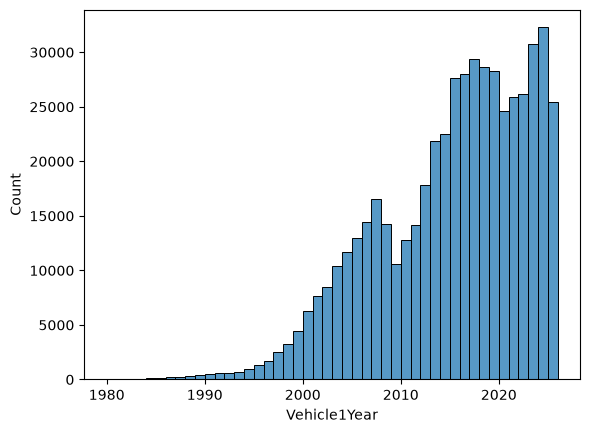

In [9]:
sns.histplot(data=crash_parties_car_data, x='Vehicle1Year', bins=46)

<Axes: xlabel='parsed_values', ylabel='count'>

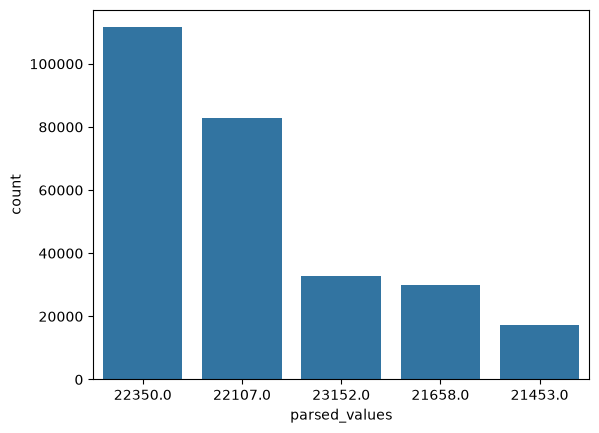

In [10]:
sns.countplot(data = crash_data_collision_factors.sort_values('parsed_values', ascending=False), x = 'parsed_values', order=crash_data_collision_factors['parsed_values'].value_counts().iloc[:5].index)

Violation Code 22350 is speeding so the most popular cause is drivers speeding

<Axes: xlabel='Vehicle1Model', ylabel='count'>

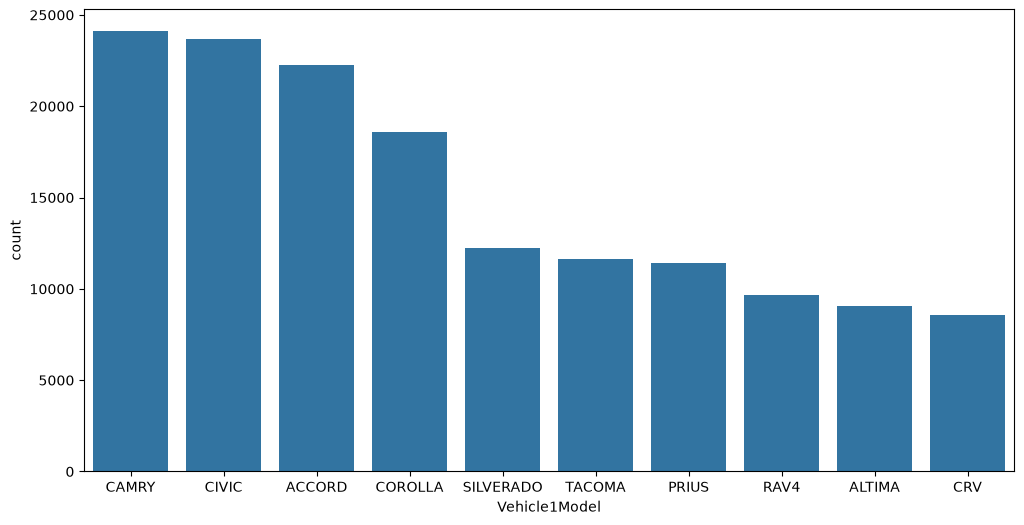

In [11]:
plt.figure(figsize=(12,6))
sns.countplot(data=crash_parties_car_data.sort_values('Vehicle1Model', ascending=False), x='Vehicle1Model', order=crash_parties_car_data['Vehicle1Model'].value_counts().iloc[:10].index, native_scale=True, )

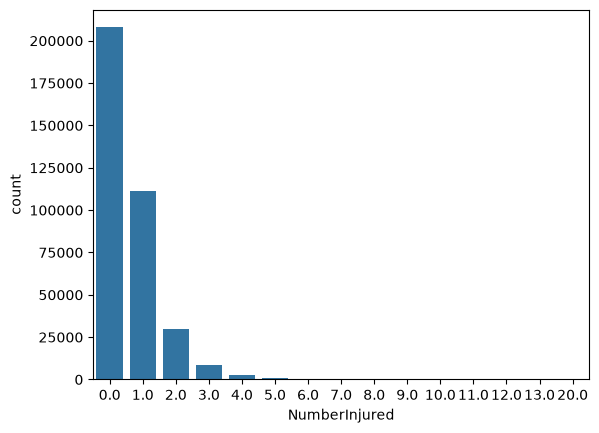

In [12]:
injury = sns.countplot(data = crash_data_collision_factors, x = 'NumberInjured')


<Axes: xlabel='NumberKilled', ylabel='count'>

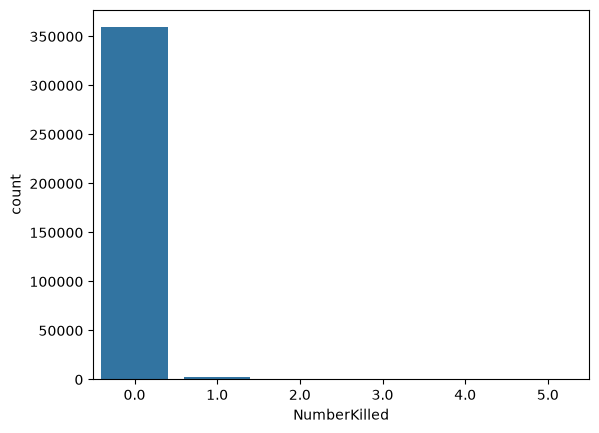

In [13]:
sns.countplot(data=crash_data_collision_factors, x='NumberKilled')

<Axes: ylabel='NumberInjured'>

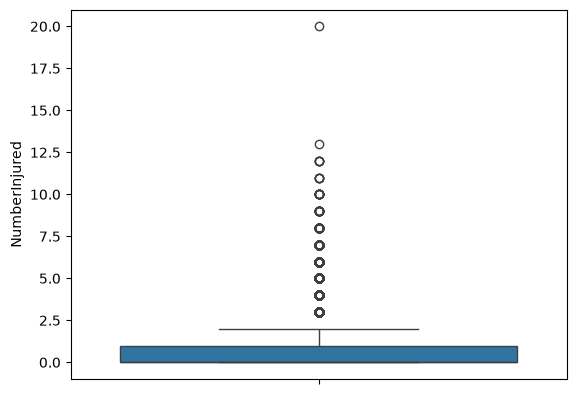

In [14]:
sns.boxplot(data=crash_data_collision_factors, y='NumberInjured')

<Axes: ylabel='NumberKilled'>

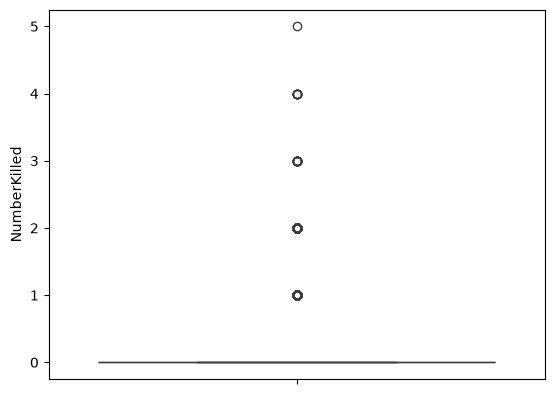

In [15]:
sns.boxplot(data=crash_data_collision_factors, y='NumberKilled')

<Axes: xlabel='Vehicle1Color', ylabel='count'>

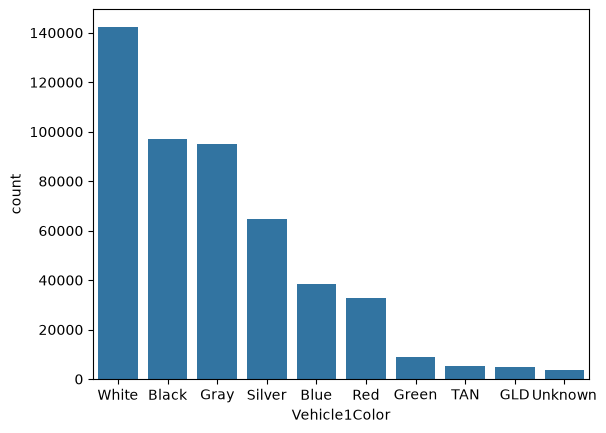

In [16]:
sns.countplot(data = crash_parties_car_data, x = 'Vehicle1Color',  order=crash_parties_car_data['Vehicle1Color'].value_counts().iloc[:10].index)

<Axes: xlabel='SpeedLimit', ylabel='count'>

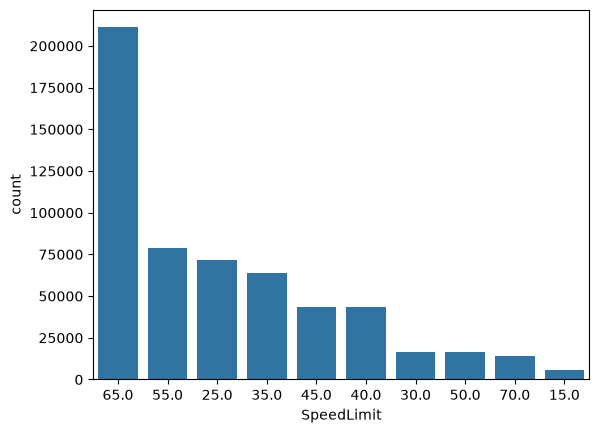

In [17]:
sns.countplot(data = crash_parties_speed_limit_data, x = 'SpeedLimit',  order=crash_parties_speed_limit_data['SpeedLimit'].value_counts().iloc[:10].index)

Joined Graphics

In [18]:
crash_parties_car_data 
crash_parties_background_data

crash_parties_car_background_data = pd.merge(crash_parties_car_data, crash_parties_background_data, on='CollisionId', how='inner')

In [19]:
crash_parties_car_background_data.head()

,CollisionId,Vehicle1Year,Vehicle1Make,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed,PartyType,Special Information,IsAtFault
0,4541901,2005.0,FORD,F-150,Gray,True,Driver,CELL PHONE NOT IN USE,False
1,4541901,2005.0,FORD,F-150,Gray,True,Driver,CELL PHONE USE UNKNOWN,True
2,4541901,2002.0,FORD,TAURUS,GLD,True,Driver,CELL PHONE NOT IN USE,False
3,4541901,2002.0,FORD,TAURUS,GLD,True,Driver,CELL PHONE USE UNKNOWN,True
4,4541900,2001.0,SATURN,ION,GLD,False,Driver,CELL PHONE NOT IN USE,False


<Axes: xlabel='Vehicle1Model', ylabel='count'>

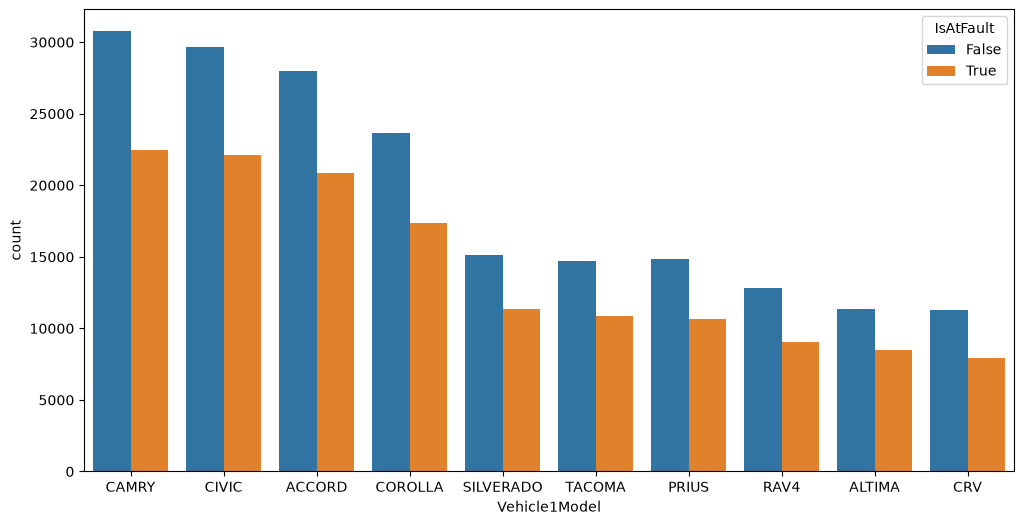

In [20]:
plt.figure(figsize=(12,6))
sns.countplot(data=crash_parties_car_background_data, x='Vehicle1Model', hue = 'IsAtFault', order=crash_parties_car_background_data['Vehicle1Model'].value_counts().iloc[:10].index)

<Axes: xlabel='Vehicle1Year', ylabel='count'>

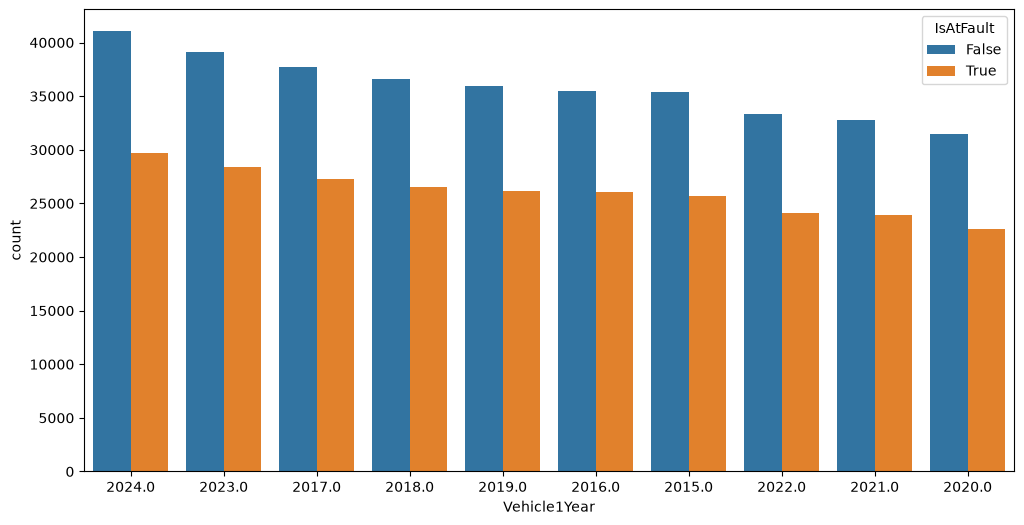

In [21]:
plt.figure(figsize=(12,6))
sns.countplot(data=crash_parties_car_background_data, x='Vehicle1Year', hue = 'IsAtFault', order=crash_parties_car_background_data['Vehicle1Year'].value_counts().iloc[:10].index)

<Axes: xlabel='Vehicle1Color', ylabel='count'>

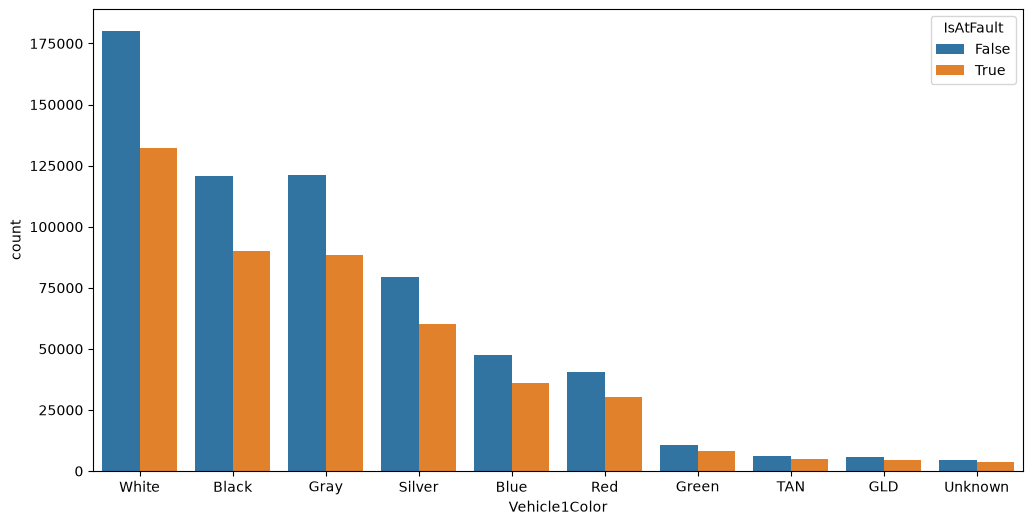

In [22]:
plt.figure(figsize=(12,6))
sns.countplot(data=crash_parties_car_background_data, x='Vehicle1Color', hue = 'IsAtFault', order=crash_parties_car_background_data['Vehicle1Color'].value_counts().iloc[:10].index)

In [23]:
crash_parties_speed_limit_data 
crash_roads_data

crash_roads_speed_limit_data = pd.merge(crash_roads_data, crash_parties_speed_limit_data, on='CollisionId', how='inner')

In [24]:
crash_roads_speed_limit_data.head()

,CollisionId,PrimaryRoad,IsFreeway,IsHighwayRelated,SpeedLimit
0,4550265,SR-79 N/B,False,True,55.0
1,4550265,SR-79 N/B,False,True,55.0
2,4550264,N EL CAMINO REAL,False,False,35.0
3,4550264,N EL CAMINO REAL,False,False,35.0
4,4550263,SR-170 S/B FROM SHERMAN WAY,True,True,65.0


In [25]:
highway_crash_roads = crash_roads_speed_limit_data[crash_roads_speed_limit_data['IsHighwayRelated'] == True]

<Axes: xlabel='PrimaryRoad', ylabel='count'>

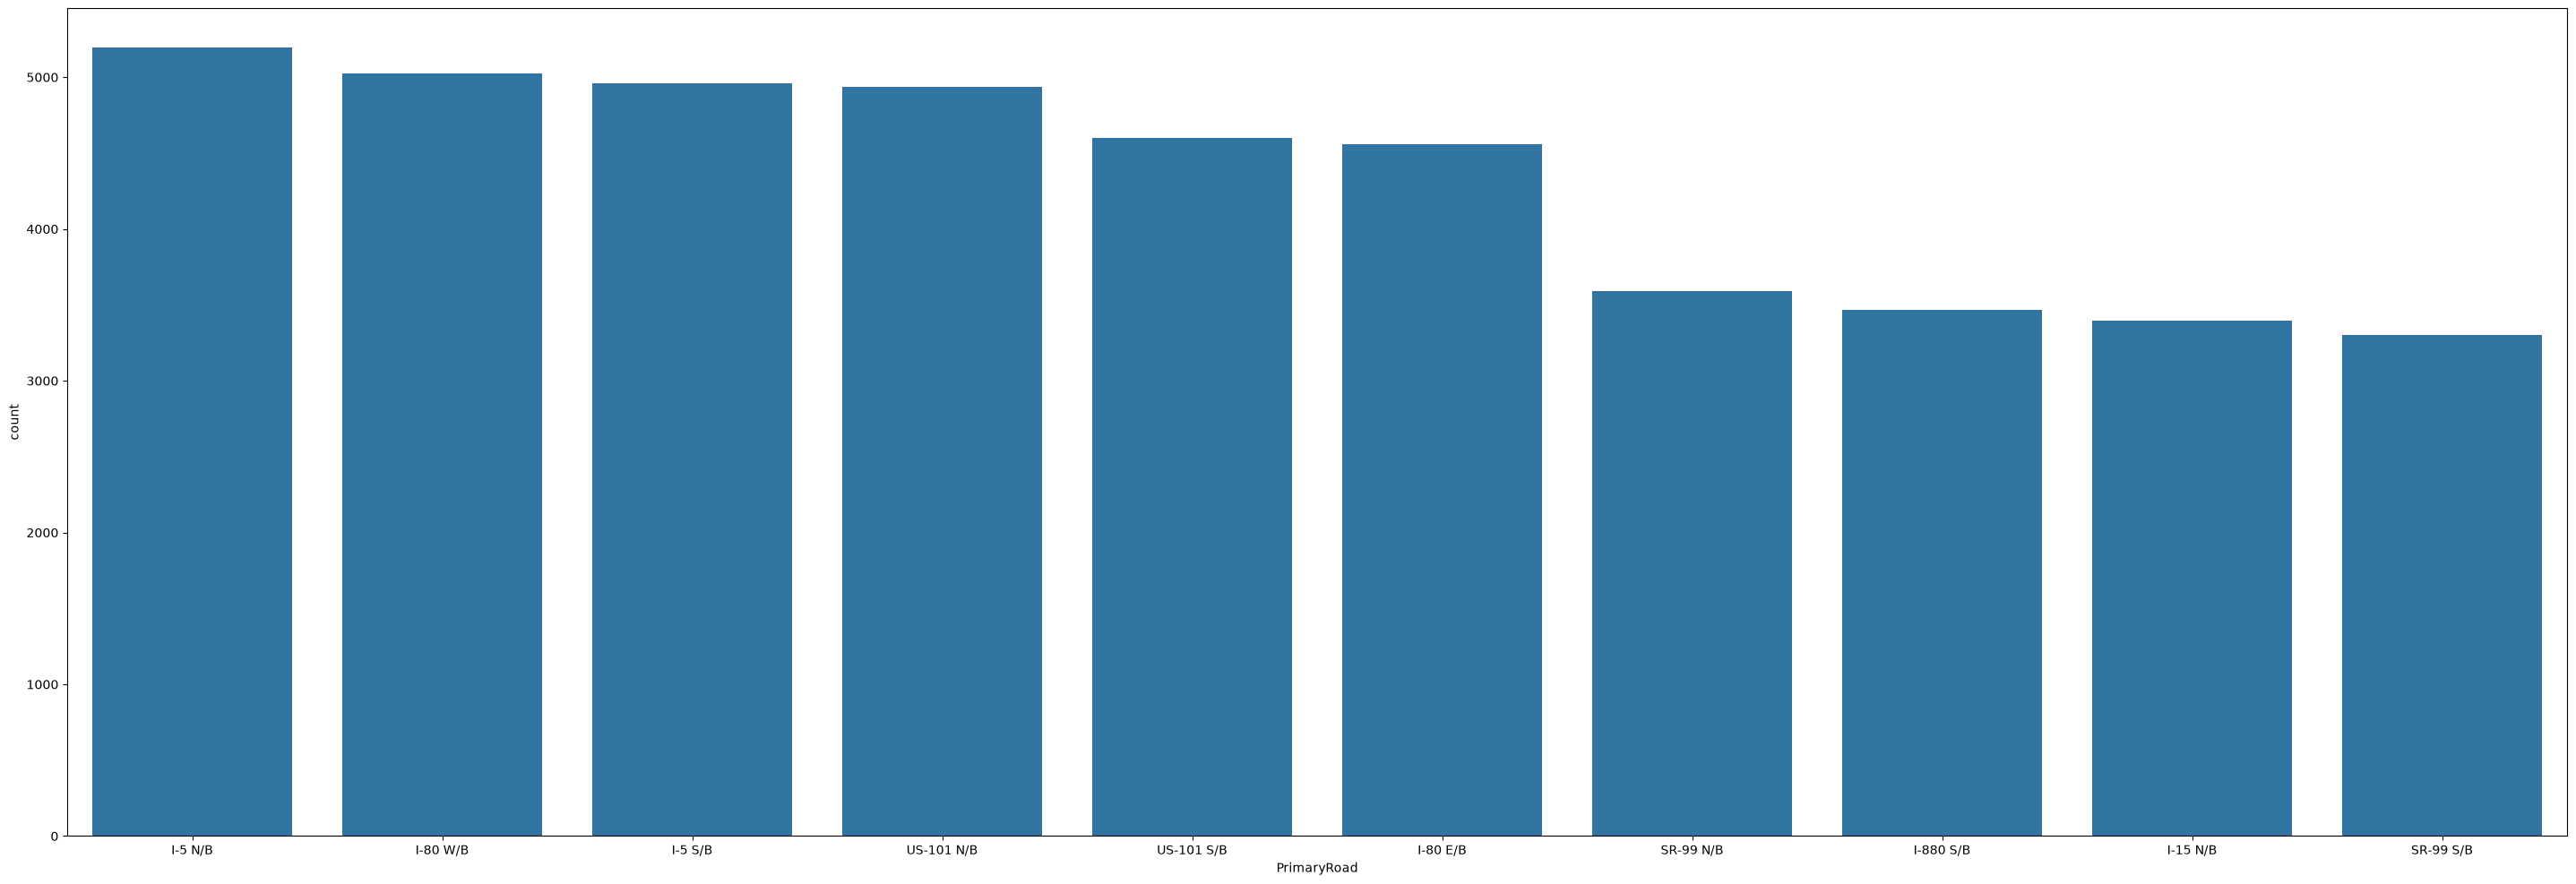

In [26]:
plt.figure(figsize=(36,12))
sns.countplot(data=highway_crash_roads, x='PrimaryRoad', order=highway_crash_roads['PrimaryRoad'].value_counts().iloc[:10].index)

In [27]:
highway_crash_roads['PrimaryRoad'] = highway_crash_roads['PrimaryRoad'].str.replace('N/B', '').str.replace('S/B', '').str.replace('E/B', '').str.replace('W/B', '') # Remove all directions

<Axes: xlabel='PrimaryRoad', ylabel='count'>

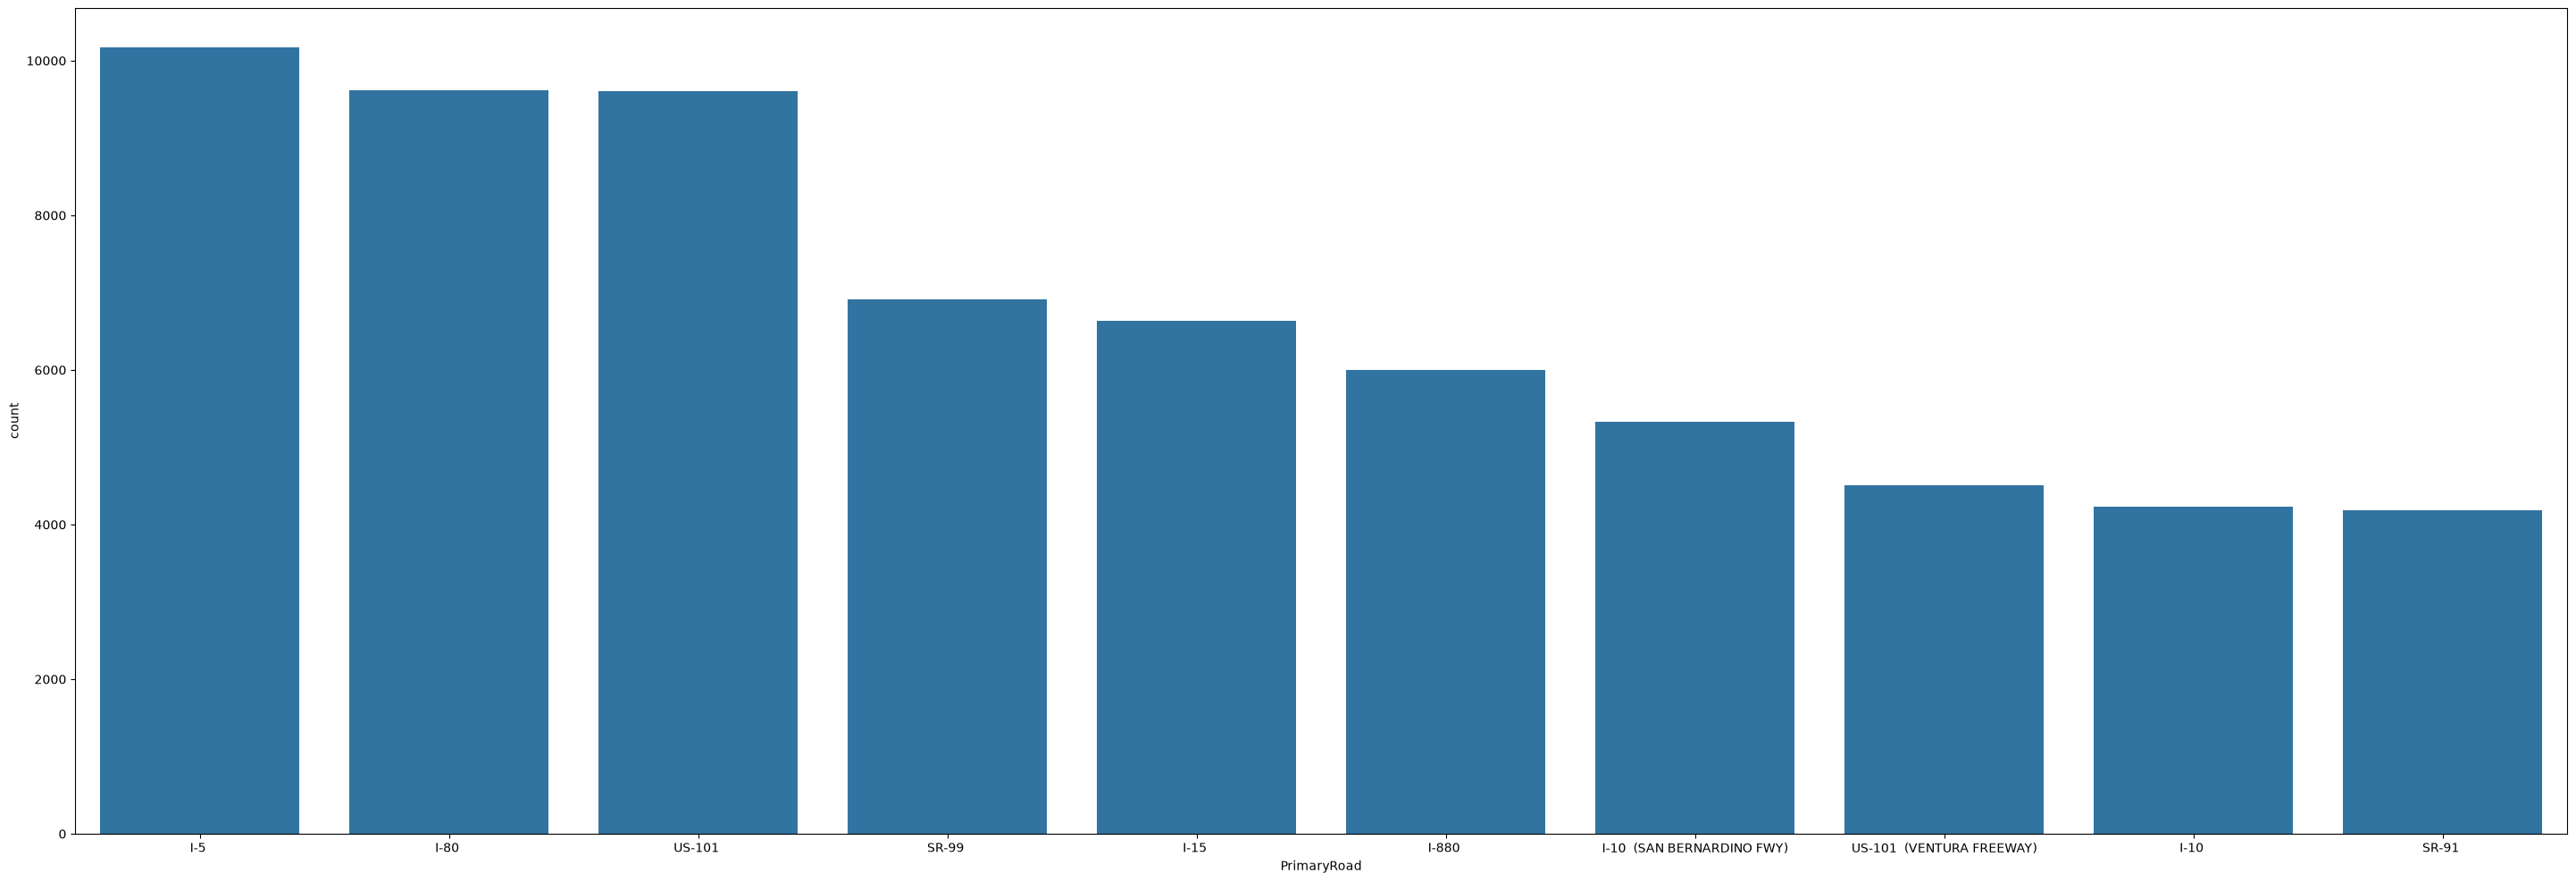

In [28]:
plt.figure(figsize=(36,12))
sns.countplot(data=highway_crash_roads, x='PrimaryRoad', order=highway_crash_roads['PrimaryRoad'].value_counts().iloc[:10].index)

In [29]:
crash_parties_car_data
crash_parties_background_data
crash_data_collision_factors

crash_parties_car_collision_background = pd.merge(crash_parties_car_background_data, crash_data_collision_factors, on='CollisionId', how='inner')
crash_parties_car_collision_background.head()

,CollisionId,Vehicle1Year,Vehicle1Make,Vehicle1Model,Vehicle1Color,V1IsVehicleTowed,PartyType,Special Information,IsAtFault,IsTowAway,MotorVehicleInvolvedWithDesc,NumberInjured,NumberKilled,Primary Collision Factor Code,Primary Collision Factor Violation,PrimaryCollisionFactorIsCited,PrimaryCollisionPartyNumber,parsed_values
0,4541901,2005.0,FORD,F-150,Gray,True,Driver,CELL PHONE NOT IN USE,False,True,OTHER MOTOR VEHICLE,1.0,0.0,A,VC 21453(a),True,1.0,21453.0
1,4541901,2005.0,FORD,F-150,Gray,True,Driver,CELL PHONE USE UNKNOWN,True,True,OTHER MOTOR VEHICLE,1.0,0.0,A,VC 21453(a),True,1.0,21453.0
2,4541901,2002.0,FORD,TAURUS,GLD,True,Driver,CELL PHONE NOT IN USE,False,True,OTHER MOTOR VEHICLE,1.0,0.0,A,VC 21453(a),True,1.0,21453.0
3,4541901,2002.0,FORD,TAURUS,GLD,True,Driver,CELL PHONE USE UNKNOWN,True,True,OTHER MOTOR VEHICLE,1.0,0.0,A,VC 21453(a),True,1.0,21453.0
4,4541899,2019.0,TOYOTA,4-RUNNER,Blue,False,Driver,CELL PHONE NOT IN USE,False,False,OTHER MOTOR VEHICLE,1.0,0.0,A,VC 21658(a),False,1.0,21658.0


<Axes: xlabel='Vehicle1Year', ylabel='NumberInjured'>

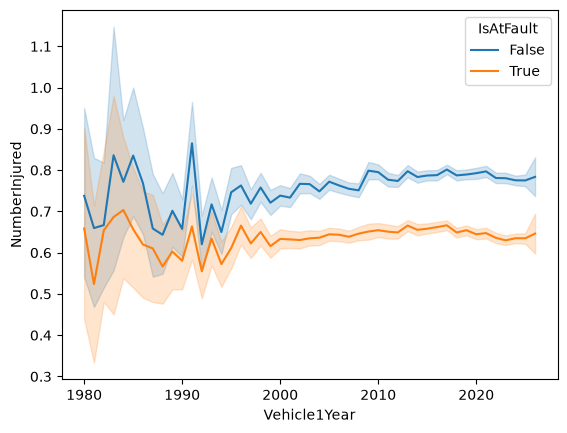

In [30]:
sns.lineplot(data=crash_parties_car_collision_background, x='Vehicle1Year', y='NumberInjured', hue='IsAtFault')

<Axes: xlabel='Vehicle1Year', ylabel='NumberKilled'>

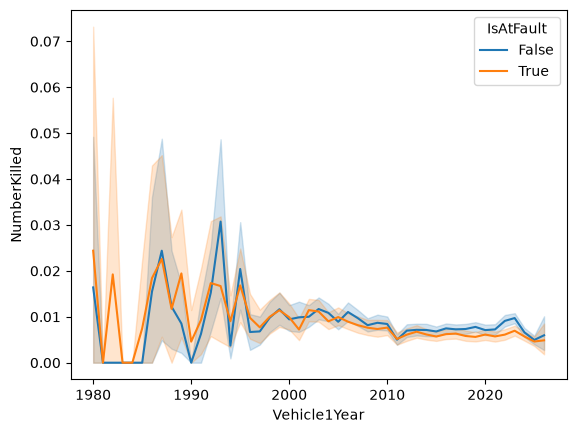

In [31]:
sns.lineplot(data=crash_parties_car_collision_background, x='Vehicle1Year', y='NumberKilled', hue='IsAtFault')

Note that when it says IsAtFault the point refers to the data point in that instance determing if the person in the accident was the one that caused the accident or not

<Axes: xlabel='V1IsVehicleTowed', ylabel='NumberInjured'>

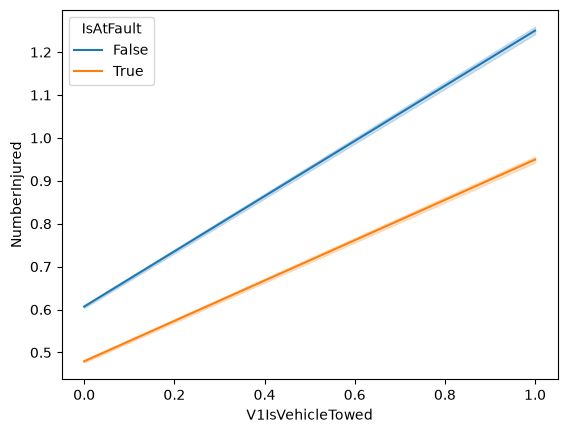

In [32]:
sns.lineplot(data=crash_parties_car_collision_background, x='V1IsVehicleTowed', y='NumberInjured', hue='IsAtFault')

<Axes: xlabel='IsTowAway', ylabel='NumberInjured'>

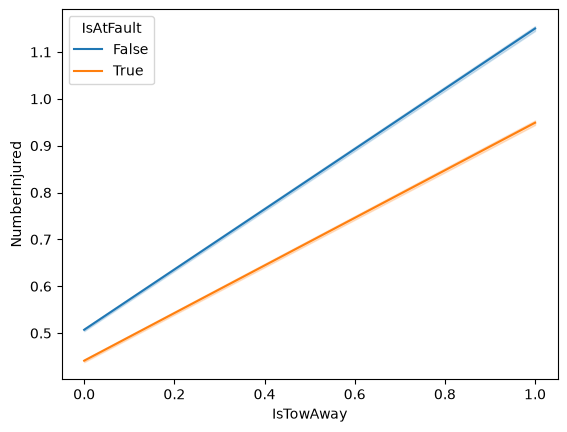

In [33]:
sns.lineplot(data=crash_parties_car_collision_background, x='IsTowAway', y='NumberInjured', hue='IsAtFault')

<Axes: xlabel='V1IsVehicleTowed', ylabel='NumberKilled'>

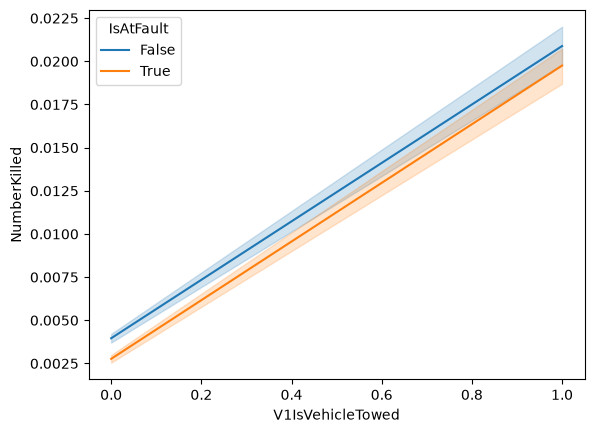

In [34]:
sns.lineplot(data=crash_parties_car_collision_background, x='V1IsVehicleTowed', y='NumberKilled', hue='IsAtFault')

<Axes: xlabel='IsTowAway', ylabel='NumberKilled'>

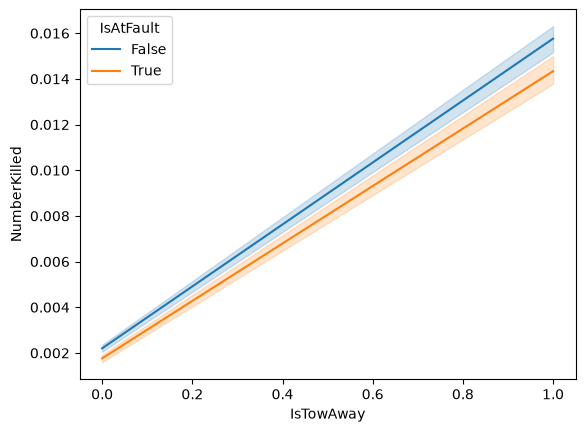

In [35]:
sns.lineplot(data=crash_parties_car_collision_background, x='IsTowAway', y='NumberKilled', hue='IsAtFault')

<Axes: xlabel='Vehicle1Model', ylabel='NumberInjured'>

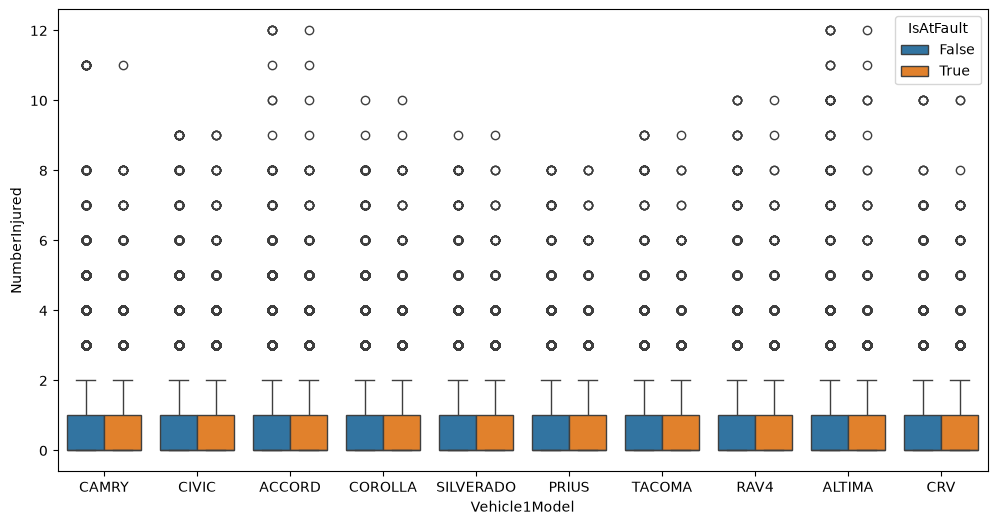

In [36]:
plt.figure(figsize=(12,6))
sns.boxplot(data=crash_parties_car_collision_background, x='Vehicle1Model', y ='NumberInjured', hue='IsAtFault', order=crash_parties_car_collision_background['Vehicle1Model'].value_counts().iloc[:10].index)

<Axes: xlabel='Vehicle1Model', ylabel='NumberKilled'>

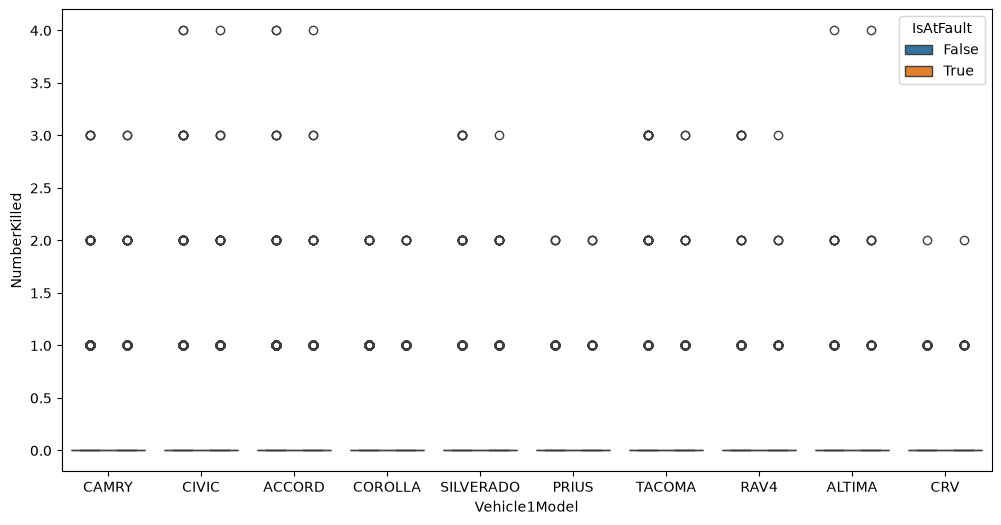

In [37]:
plt.figure(figsize=(12,6))
sns.boxplot(data=crash_parties_car_collision_background, x='Vehicle1Model', y ='NumberKilled', hue='IsAtFault', order=crash_parties_car_collision_background['Vehicle1Model'].value_counts().iloc[:10].index)

In [38]:
crash_parties_car_collision_background['PartyType'].value_counts()

PartyType
Driver           990599
ParkedVehicle     74868
Pedestrian         5742
Bicyclist          5137
Other              3461
Operator            305
Name: count, dtype: int64

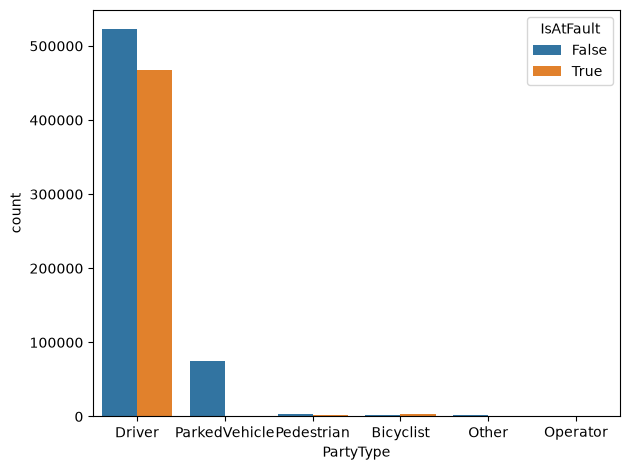

In [45]:
ax = sns.countplot(data=crash_parties_car_collision_background, x='PartyType', hue='IsAtFault')
plt.tight_layout()


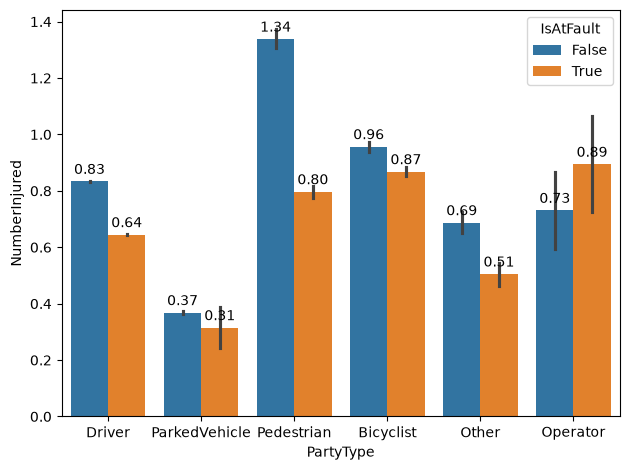

In [46]:
ax = sns.barplot(data=crash_parties_car_collision_background, x='PartyType', y='NumberInjured', hue='IsAtFault')
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

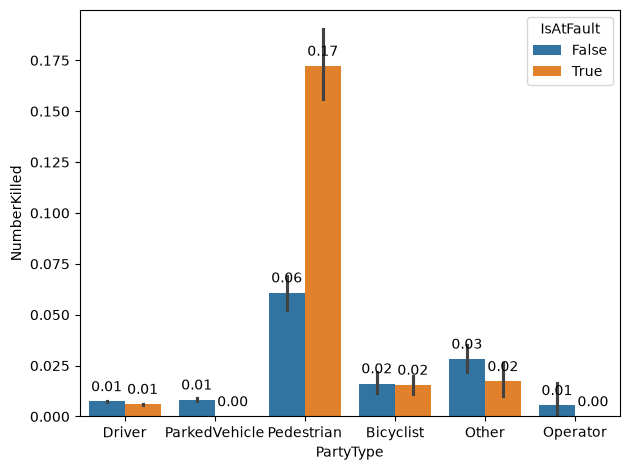

In [44]:
ax = sns.barplot(data=crash_parties_car_collision_background, x='PartyType', y='NumberKilled', hue='IsAtFault')
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=5)


Conclusion

In conclusion, it appears that most accidents do not occur in injuries or death. It also appears that pedestrians are the ones most at fault here when they do get injuries or killed. However to not much surprise, it does appear that people in motor vehicles are the ones causing the vast majority of accidents both at fault and not at fault. 
It also seems after a certain car year, people are less likely to be physically killed from an accident so it appears that newer cars are doing something when it comes to protecting people, preventing injuries is showing the opposite. 

It also appears that drivers are the main reason why accidents happen so it really shows that drivers might be the most dangerous factor when it comes to motor saftey. However when it comes to deaths and injuries, looking at the 10 most popular car models, it ranges from 0-2 people injuried on average in an accident and near 0 for deaths. However this does not excuse outliers happening as it is present across the board for these popular models. 

Also it appears that relatively newer cars cannot be used as a reason to say that you are less likely to get into an accident as it does within line with other years or even higher than previous years. For color, it seems that picking a color will also not affect your chances as well as much as the stereotype that being in a bright color like red makes people drive more agressive.  

It also appears that more mainstream vehicles from Honda, Toyota, Chevorlet and Nissan are the most popular vehicles to be involved in an accident. Along with most of these accidents happen on a high speed area such as a freeway / highway such as I-5 which is known to be a straight state interway. 